In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


--- 1. INGESTA DE DATOS PARA LA CAMPAÑA ---
✅ Ingesta completa: 4749 ofertas cargadas.

--- 2. Segmentando el universo en 'Canónico' vs. 'Incentivado' ---
Grupo de Control: 2191 ofertas | Grupo de Tratamiento: 2444 ofertas

--- 3. Creando Benchmark Canónico por 'Bucket' de Tiempo ---
Benchmark Canónico:


simplified_category,Black,Mid-Tier,UberX
time_bucket,,,
0-5min,$nan,$47.83,$40.05
5-10min,$66.61,$43.40,$44.80
10-15min,$108.03,$62.99,$59.60
15-20min,$182.33,$83.13,$73.95
20-30min,$221.83,$115.62,$98.07
30-60min,$471.81,$179.94,$147.97
60-120min,$nan,$303.67,$245.32



--- 4. Ejecutando Auditoría Forense ---

--- 5. El Veredicto: Probando la Hipótesis ---
Residuo Estratégico Promedio (Subsidio Oculto): $4.96 MXN por viaje
P-value: 0.0000

❌ Veredicto: No se encontró evidencia estadística suficiente para confirmar la hipótesis.


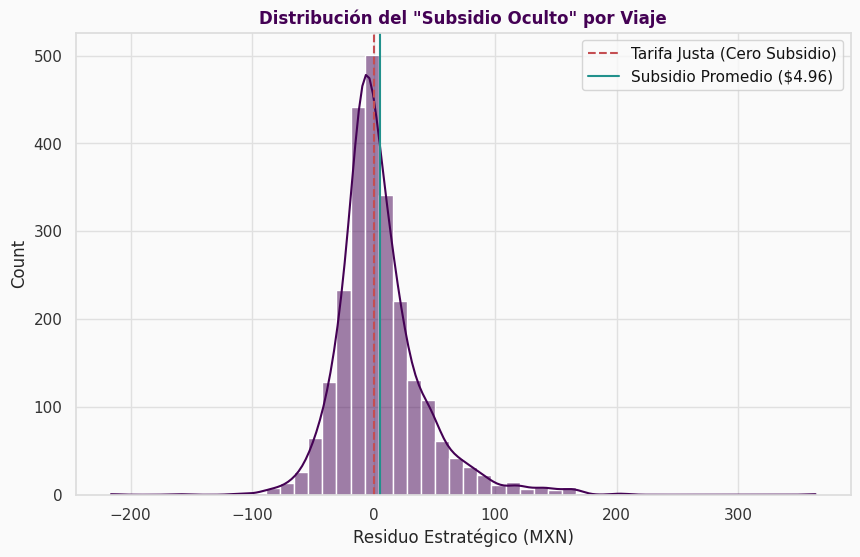

In [2]:
# ==============================================================================
# CELL 1: CAMPAÑA DEL "SUBSIDIO OCULTO" (SIN ML)
# ==============================================================================
# Purpose: Ejecutar la investigación del "Subsidio Oculto" usando un método
#          de bucketing empírico en lugar de un modelo de ML.
# ==============================================================================

from scipy import stats

if 'db_engine' in locals():

    print("--- 1. INGESTA DE DATOS PARA LA CAMPAÑA ---")

    # 1.1. QUERY UNIFICADO (Trae todas las variables de incentivos y estructura)
    query_subsidy = """
    SELECT
        o.offer_id,
        o.upfront_fare,
        o.est_trip_time_sec,
        o.is_surge,
        o.surge_amount,
        o.is_turbo_plus,
        o.turbo_plus_amount,
        pc.category_name as product_category
    FROM offers o
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    WHERE o.est_trip_time_sec > 0
      AND o.upfront_fare IS NOT NULL
    """

    try:
        df_subsidy = pd.read_sql_query(query_subsidy, db_engine)
        print(f"✅ Ingesta completa: {len(df_subsidy)} ofertas cargadas.")

        # 1.2. FEATURE ENGINEERING (Simplificación de Categoría)
        def simplify_category(category_name):
            if pd.isna(category_name): return 'Other'
            if 'uberx' in category_name.lower(): return 'UberX'
            elif 'comfort' in category_name.lower() or 'business' in category_name.lower(): return 'Mid-Tier'
            elif 'black' in category_name.lower(): return 'Black'
            else: return 'Other'
        df_subsidy['simplified_category'] = df_subsidy['product_category'].apply(simplify_category)
        df_subsidy = df_subsidy[df_subsidy['simplified_category'].isin(['UberX', 'Mid-Tier', 'Black'])].copy()

        # --- 2. SEGMENTACIÓN DEL UNIVERSO ---
        print("\n--- 2. Segmentando el universo en 'Canónico' vs. 'Incentivado' ---")

        # 2.1. Grupo de Control (Canónicos)
        df_control = df_subsidy[(df_subsidy['is_surge'] == 0) & (df_subsidy['is_turbo_plus'] == 0)].copy()

        # 2.2. Grupo de Tratamiento (Incentivados)
        df_treatment = df_subsidy[(df_subsidy['is_surge'] == 1) | (df_subsidy['is_turbo_plus'] == 1)].copy()
        df_treatment['base_fare_real'] = df_treatment['upfront_fare'] - df_treatment['surge_amount'].fillna(0) - df_treatment['turbo_plus_amount'].fillna(0)

        print(f"Grupo de Control: {len(df_control)} ofertas | Grupo de Tratamiento: {len(df_treatment)} ofertas")

        # --- 3. CREACIÓN DEL BENCHMARK CANÓNICO ---
        print("\n--- 3. Creando Benchmark Canónico por 'Bucket' de Tiempo ---")

        # 3.1. Crear "Buckets" de Tiempo
        time_bins = [0, 300, 600, 900, 1200, 1800, 3600, 7200] # 0, 5, 10, 15, 20, 30, 60, 120 min
        time_labels = ['0-5min', '5-10min', '10-15min', '15-20min', '20-30min', '30-60min', '60-120min']

        df_control['time_bucket'] = pd.cut(df_control['est_trip_time_sec'], bins=time_bins, labels=time_labels, right=False)
        df_treatment['time_bucket'] = pd.cut(df_treatment['est_trip_time_sec'], bins=time_bins, labels=time_labels, right=False)

        # 3.2. Calcular el Precio Canónico por Bucket y Categoría
        canonical_benchmark = df_control.groupby(['simplified_category', 'time_bucket'])['upfront_fare'].mean().reset_index()
        canonical_benchmark.rename(columns={'upfront_fare': 'precio_canonico_promedio'}, inplace=True)

        print("Benchmark Canónico:")
        display(canonical_benchmark.pivot(index='time_bucket', columns='simplified_category', values='precio_canonico_promedio').style.format('${:,.2f}'))

        # --- 4. AUDITORÍA FORENSE ---
        print("\n--- 4. Ejecutando Auditoría Forense ---")

        # 4.1. Unir el Benchmark al Grupo de Tratamiento
        df_audit = pd.merge(df_treatment, canonical_benchmark, on=['simplified_category', 'time_bucket'], how='left')

        # 4.2. Calcular el Residuo Estratégico
        df_audit['strategic_residual'] = df_audit['base_fare_real'] - df_audit['precio_canonico_promedio']

        # --- 5. EL VEREDICTO ---
        print("\n--- 5. El Veredicto: Probando la Hipótesis ---")

        # Filtramos nulos por si algún bucket no tenía datos
        residuals = df_audit['strategic_residual'].dropna()

        # Ejecutamos el t-test
        t_stat, p_value = stats.ttest_1samp(residuals, 0)

        mean_residual = residuals.mean()

        print(f"Residuo Estratégico Promedio (Subsidio Oculto): ${mean_residual:,.2f} MXN por viaje")
        print(f"P-value: {p_value:.4f}")

        if p_value < 0.05 and mean_residual < 0:
            print("\n✅ Veredicto: La hipótesis del 'Subsidio Oculto' es **CONFIRMADA** con una significancia estadística del 95%.")
        else:
            print("\n❌ Veredicto: No se encontró evidencia estadística suficiente para confirmar la hipótesis.")

        # Visualización de la distribución del residuo
        plt.figure(figsize=(10,6))
        sns.histplot(residuals, bins=50, kde=True, color=OPUS_PURPLE)
        plt.axvline(x=0, color='r', linestyle='--', label='Tarifa Justa (Cero Subsidio)')
        plt.axvline(x=mean_residual, color=OPUS_TEAL, linestyle='-', label=f'Subsidio Promedio (${mean_residual:,.2f})')
        plt.title('Distribución del "Subsidio Oculto" por Viaje', color=OPUS_PURPLE)
        plt.xlabel('Residuo Estratégico (MXN)')
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"🔴 ERROR CRÍTICO durante la campaña: {e}")

else:
    print("🔴 No se puede ejecutar la campaña. El `db_engine` no está definido.")


# **INVESTIGACIÓN: EL "SUBSIDIO OCULTO" (FASE DE COMPARACIÓN)**

Esta investigación busca validar o refutar la hipótesis de que la plataforma ajusta la tarifa base de los viajes cuando se aplican incentivos. Para lograrlo sin la complejidad de un modelo de ML, empleamos un método de **comparación de grupos de control**.

### **Metodología: Aislamiento y Comparación Empírica**

**1. Segmentación del Universo:**
El `dataset` completo de ofertas se divide en dos grupos mutuamente excluyentes:
- **Grupo de Control ("Canónico"):** Ofertas puras, sin ningún tipo de incentivo (`Surge`, `Turbo+`, etc.). Su `upfront_fare` es, por definición, la tarifa base.
- **Grupo de Tratamiento ("Incentivado"):** Ofertas que incluyen al menos un incentivo.

**2. El "Desnudamiento" del Incentivo:**
Para poder comparar "peras con peras", a cada oferta del Grupo de Tratamiento se le calcula su **"tarifa base real"** restando el valor monetario de todos los incentivos aplicados.

**3. La Comparación Directa:**
El núcleo de este análisis es la comparación directa de la tarifa base promedio entre el grupo "Canónico" y el grupo "Incentivado (Desnudo)". Esta comparación se realiza en tres niveles de granularidad para asegurar la robustez del hallazgo:
- **Global:** Un promedio general.
- **Por Tier:** Desglosado por `UberX`, `Mid-Tier` y `Black`.
- **Por Bucket de Tiempo:** Segmentado por la duración estimada del viaje.

El objetivo es observar si existe una diferencia sistemática y estadísticamente significativa entre ambos grupos.



--- 1. INGESTA Y SEGMENTACIÓN ---
Grupo Canónico (Control): 2063 ofertas
Grupo Incentivado (Tratamiento): 2686 ofertas



### 2.1. Comparación Global de Tarifas Base

,mean,median,count
group,,,
Canónico,$110.95,$97.54,"$2,063.00"
Incentivado (Desnudo),$119.88,$108.73,"$2,686.00"



### 2.2. Comparación por Tier (Categoría Simplificada)


### 2.3. Comparación por Bucket de Tiempo

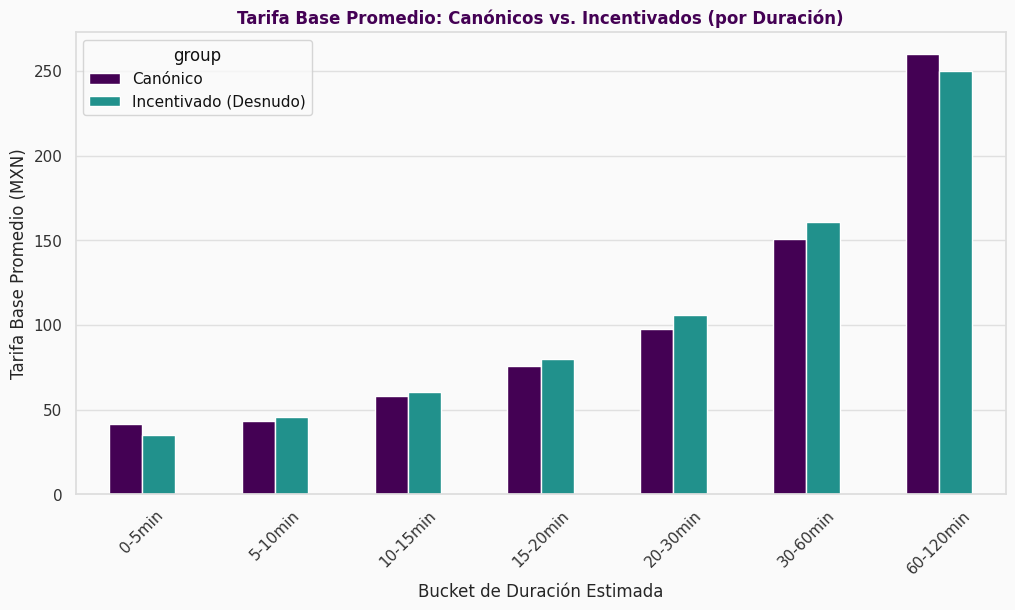

In [3]:
# ==============================================================================
# CELL 1: CAMPAÑA "SUBSIDIO OCULTO" - FASE 1: SEGMENTACIÓN Y COMPARACIÓN
# ==============================================================================
# Purpose: Implementar el Stage 1 y 2 del Protocolo "Subsidio Oculto" (v2.0).
#          Esta celda aísla los grupos de control y tratamiento, y realiza
#          una comparación directa de sus tarifas base a múltiples niveles.
# ==============================================================================

from IPython.display import display, Markdown
from scipy import stats

# --- MANIFIESTO METODOLÓGICO ---

markdown_explanation = """
# **INVESTIGACIÓN: EL "SUBSIDIO OCULTO" (FASE DE COMPARACIÓN)**

Esta investigación busca validar o refutar la hipótesis de que la plataforma ajusta la tarifa base de los viajes cuando se aplican incentivos. Para lograrlo sin la complejidad de un modelo de ML, empleamos un método de **comparación de grupos de control**.

### **Metodología: Aislamiento y Comparación Empírica**

**1. Segmentación del Universo:**
El `dataset` completo de ofertas se divide en dos grupos mutuamente excluyentes:
- **Grupo de Control ("Canónico"):** Ofertas puras, sin ningún tipo de incentivo (`Surge`, `Turbo+`, etc.). Su `upfront_fare` es, por definición, la tarifa base.
- **Grupo de Tratamiento ("Incentivado"):** Ofertas que incluyen al menos un incentivo.

**2. El "Desnudamiento" del Incentivo:**
Para poder comparar "peras con peras", a cada oferta del Grupo de Tratamiento se le calcula su **"tarifa base real"** restando el valor monetario de todos los incentivos aplicados.

**3. La Comparación Directa:**
El núcleo de este análisis es la comparación directa de la tarifa base promedio entre el grupo "Canónico" y el grupo "Incentivado (Desnudo)". Esta comparación se realiza en tres niveles de granularidad para asegurar la robustez del hallazgo:
- **Global:** Un promedio general.
- **Por Tier:** Desglosado por `UberX`, `Mid-Tier` y `Black`.
- **Por Bucket de Tiempo:** Segmentado por la duración estimada del viaje.

El objetivo es observar si existe una diferencia sistemática y estadísticamente significativa entre ambos grupos.
"""
display(Markdown(markdown_explanation))


# --- EJECUCIÓN DEL CÓDIGO ---

if 'db_engine' in locals():

    print("\n--- 1. INGESTA Y SEGMENTACIÓN ---")

    query_subsidy = """
    SELECT
        o.offer_id, o.upfront_fare, o.est_trip_time_sec,
        o.is_surge, o.surge_amount, o.is_turbo_plus, o.turbo_plus_amount,
        o.is_reservation, o.reservation_amount, o.is_priority, o.priority_amount,
        pc.category_name as product_category
    FROM offers o
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    WHERE o.est_trip_time_sec > 0 AND o.upfront_fare IS NOT NULL
    """

    try:
        df_subsidy = pd.read_sql_query(query_subsidy, db_engine)

        def simplify_category(cat):
            if pd.isna(cat): return 'Other'
            if 'uberx' in cat.lower(): return 'UberX'
            elif 'comfort' in cat.lower() or 'business' in cat.lower(): return 'Mid-Tier'
            elif 'black' in cat.lower(): return 'Black'
            else: return 'Other'
        df_subsidy['simplified_category'] = df_subsidy['product_category'].apply(simplify_category)

        incentive_flags = ['is_surge', 'is_turbo_plus', 'is_reservation', 'is_priority']
        df_subsidy[incentive_flags] = df_subsidy[incentive_flags].fillna(0).astype(int)

        df_control = df_subsidy[df_subsidy[incentive_flags].sum(axis=1) == 0].copy()
        df_control['base_fare'] = df_control['upfront_fare']
        df_control['group'] = 'Canónico'

        df_treatment = df_subsidy[df_subsidy[incentive_flags].sum(axis=1) > 0].copy()
        df_treatment['base_fare'] = (df_treatment['upfront_fare'] -
                                     df_treatment['surge_amount'].fillna(0) -
                                     df_treatment['turbo_plus_amount'].fillna(0) -
                                     df_treatment['reservation_amount'].fillna(0) -
                                     df_treatment['priority_amount'].fillna(0))
        df_treatment['group'] = 'Incentivado (Desnudo)'

        print(f"Grupo Canónico (Control): {len(df_control)} ofertas")
        print(f"Grupo Incentivado (Tratamiento): {len(df_treatment)} ofertas")

        df_comparison = pd.concat([df_control, df_treatment])

        # --- 2. ANÁLISIS COMPARATIVO ---

        display(Markdown("\n### 2.1. Comparación Global de Tarifas Base"))
        global_comparison = df_comparison.groupby('group')['base_fare'].agg(['mean', 'median', 'count'])
        display(global_comparison.style.format('${:,.2f}'))

        display(Markdown("\n### 2.2. Comparación por Tier (Categoría Simplificada)"))
        tier_comparison = df_comparison.groupby(['group', 'simplified_category'])['base_fare'].agg(['mean', 'median', 'count'])
        display(tier_comparison.style.format('${:,.2f}'))

        display(Markdown("\n### 2.3. Comparación por Bucket de Tiempo"))
        time_bins = [0, 300, 600, 900, 1200, 1800, 3600, 7200]
        time_labels = ['0-5min', '5-10min', '10-15min', '15-20min', '20-30min', '30-60min', '60-120min']
        df_comparison['time_bucket'] = pd.cut(df_comparison['est_trip_time_sec'], bins=time_bins, labels=time_labels, right=False)

        time_comparison = df_comparison.groupby(['time_bucket', 'group'])['base_fare'].mean().unstack()

        time_comparison.plot(kind='bar', figsize=(12, 6), color=[OPUS_PURPLE, OPUS_TEAL])
        plt.title('Tarifa Base Promedio: Canónicos vs. Incentivados (por Duración)', color=OPUS_PURPLE)
        plt.ylabel('Tarifa Base Promedio (MXN)')
        plt.xlabel('Bucket de Duración Estimada')
        plt.xticks(rotation=45)
        plt.grid(axis='x')
        plt.show()

        global df_comp_global
        df_comp_global = df_comparison

    except Exception as e:
        print(f"🔴 ERROR CRÍTICO durante la campaña: {e}")

else:
    print("🔴 No se puede ejecutar la campaña. El `db_engine` no está definido.")

--- 1. INGESTA DE DATOS PARA LA CAMPAÑA (AISLAMIENTO DE TURBO+) ---

--- 2. Segmentando el universo... ---
Grupo Canónico (Control Puro): 2063 ofertas
Grupo Turbo+ (Tratamiento Puro): 871 ofertas



### 3.1. Comparación Global de Tarifas Base (Turbo+ vs. Puro)

,mean,median,count
group,,,
Canónico (Puro),$110.95,$97.54,"$2,063.00"
Turbo+ (Desnudo),$116.51,$107.23,$871.00



### 3.2. Comparación por Tier (Turbo+ vs. Puro)


### 3.3. Comparación por Bucket de Tiempo (Turbo+ vs. Puro)

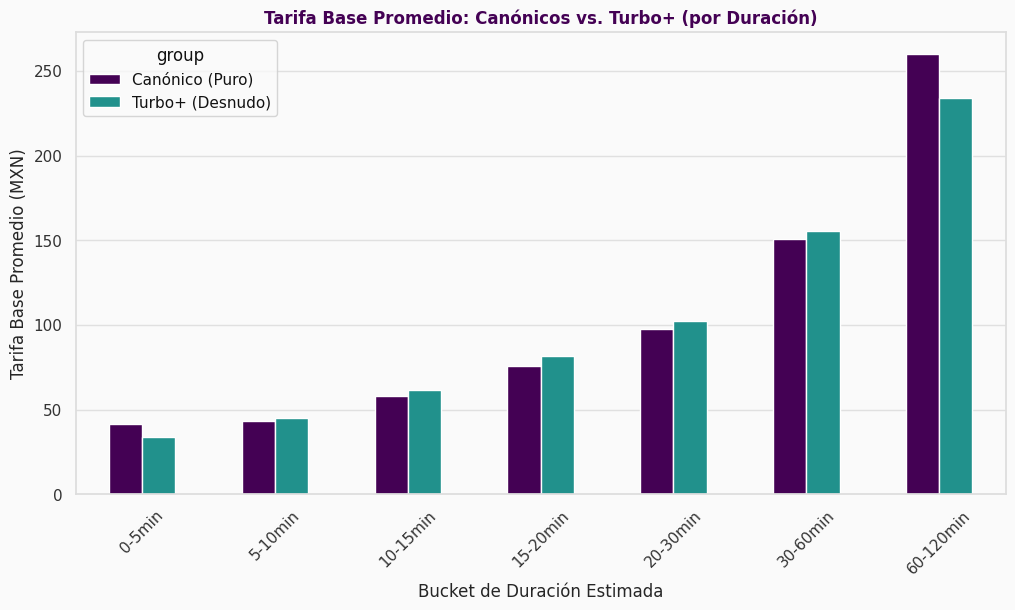

In [4]:
# ==============================================================================
# CELL 1.1: CAMPAÑA "SUBSIDIO OCULTO" (ANÁLISIS DE TURBO+)
# ==============================================================================
# Purpose: Aislar y analizar el efecto del incentivo `Turbo+` en la tarifa base,
#          comparándolo con un grupo de control puro.
# ==============================================================================

from IPython.display import display, Markdown

if 'db_engine' in locals():

    print("--- 1. INGESTA DE DATOS PARA LA CAMPAÑA (AISLAMIENTO DE TURBO+) ---")

    # Mantenemos el query original, ya que necesitamos todos los datos para la segmentación
    query_subsidy = """
    SELECT
        o.offer_id, o.upfront_fare, o.est_trip_time_sec,
        o.is_surge, o.surge_amount, o.is_turbo_plus, o.turbo_plus_amount,
        o.is_reservation, o.reservation_amount, o.is_priority, o.priority_amount,
        pc.category_name as product_category
    FROM offers o
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    WHERE o.est_trip_time_sec > 0 AND o.upfront_fare IS NOT NULL
    """

    try:
        df_subsidy = pd.read_sql_query(query_subsidy, db_engine)

        def simplify_category(cat):
            if pd.isna(cat): return 'Other'
            if 'uberx' in cat.lower(): return 'UberX'
            elif 'comfort' in cat.lower() or 'business' in cat.lower(): return 'Mid-Tier'
            elif 'black' in cat.lower(): return 'Black'
            else: return 'Other'
        df_subsidy['simplified_category'] = df_subsidy['product_category'].apply(simplify_category)

        # --- 2. SEGMENTACIÓN DEL UNIVERSO (AISLAMIENTO QUIRÚRGICO) ---
        print("\n--- 2. Segmentando el universo... ---")

        # Grupo de Control (Canónico): SIN NINGÚN INCENTIVO
        df_control = df_subsidy[
            (df_subsidy['is_surge'].fillna(0) == 0) &
            (df_subsidy['is_turbo_plus'].fillna(0) == 0) &
            (df_subsidy['is_reservation'].fillna(0) == 0) &
            (df_subsidy['is_priority'].fillna(0) == 0)
        ].copy()
        df_control['base_fare'] = df_control['upfront_fare']
        df_control['group'] = 'Canónico (Puro)'

        # Grupo de Tratamiento (Turbo+ Puro): SOLO TURBO+, NINGÚN OTRO INCENTIVO
        df_treatment_turbo = df_subsidy[
            (df_subsidy['is_turbo_plus'].fillna(0) == 1) &
            (df_subsidy['is_surge'].fillna(0) == 0) &
            (df_subsidy['is_reservation'].fillna(0) == 0) &
            (df_subsidy['is_priority'].fillna(0) == 0)
        ].copy()
        df_treatment_turbo['base_fare'] = (df_treatment_turbo['upfront_fare'] -
                                           df_treatment_turbo['turbo_plus_amount'].fillna(0))
        df_treatment_turbo['group'] = 'Turbo+ (Desnudo)'

        print(f"Grupo Canónico (Control Puro): {len(df_control)} ofertas")
        print(f"Grupo Turbo+ (Tratamiento Puro): {len(df_treatment_turbo)} ofertas")

        # Unimos solo los dos grupos de interés
        df_comparison_turbo = pd.concat([df_control, df_treatment_turbo])

        # --- 3. ANÁLISIS COMPARATIVO (TURBO+ vs. PURO) ---

        display(Markdown("\n### 3.1. Comparación Global de Tarifas Base (Turbo+ vs. Puro)"))
        global_comparison = df_comparison_turbo.groupby('group')['base_fare'].agg(['mean', 'median', 'count'])
        display(global_comparison.style.format('${:,.2f}'))

        display(Markdown("\n### 3.2. Comparación por Tier (Turbo+ vs. Puro)"))
        tier_comparison = df_comparison_turbo.groupby(['group', 'simplified_category'])['base_fare'].agg(['mean', 'median', 'count'])
        display(tier_comparison.style.format('${:,.2f}'))

        display(Markdown("\n### 3.3. Comparación por Bucket de Tiempo (Turbo+ vs. Puro)"))
        time_bins = [0, 300, 600, 900, 1200, 1800, 3600, 7200]
        time_labels = ['0-5min', '5-10min', '10-15min', '15-20min', '20-30min', '30-60min', '60-120min']
        df_comparison_turbo['time_bucket'] = pd.cut(df_comparison_turbo['est_trip_time_sec'], bins=time_bins, labels=time_labels, right=False)

        time_comparison_turbo = df_comparison_turbo.groupby(['time_bucket', 'group'])['base_fare'].mean().unstack()

        time_comparison_turbo.plot(kind='bar', figsize=(12, 6), color=[OPUS_PURPLE, OPUS_TEAL])
        plt.title('Tarifa Base Promedio: Canónicos vs. Turbo+ (por Duración)', color=OPUS_PURPLE)
        plt.ylabel('Tarifa Base Promedio (MXN)')
        plt.xlabel('Bucket de Duración Estimada')
        plt.xticks(rotation=45)
        plt.grid(axis='x')
        plt.show()

        global df_comp_turbo
        df_comp_turbo = df_comparison_turbo

    except Exception as e:
        print(f"🔴 ERROR CRÍTICO durante la campaña: {e}")

else:
    print("🔴 No se puede ejecutar la campaña. El `db_engine` no está definido.")


### 2.1. Comparación por Bucket de Tiempo (Resolución de 10 minutos)

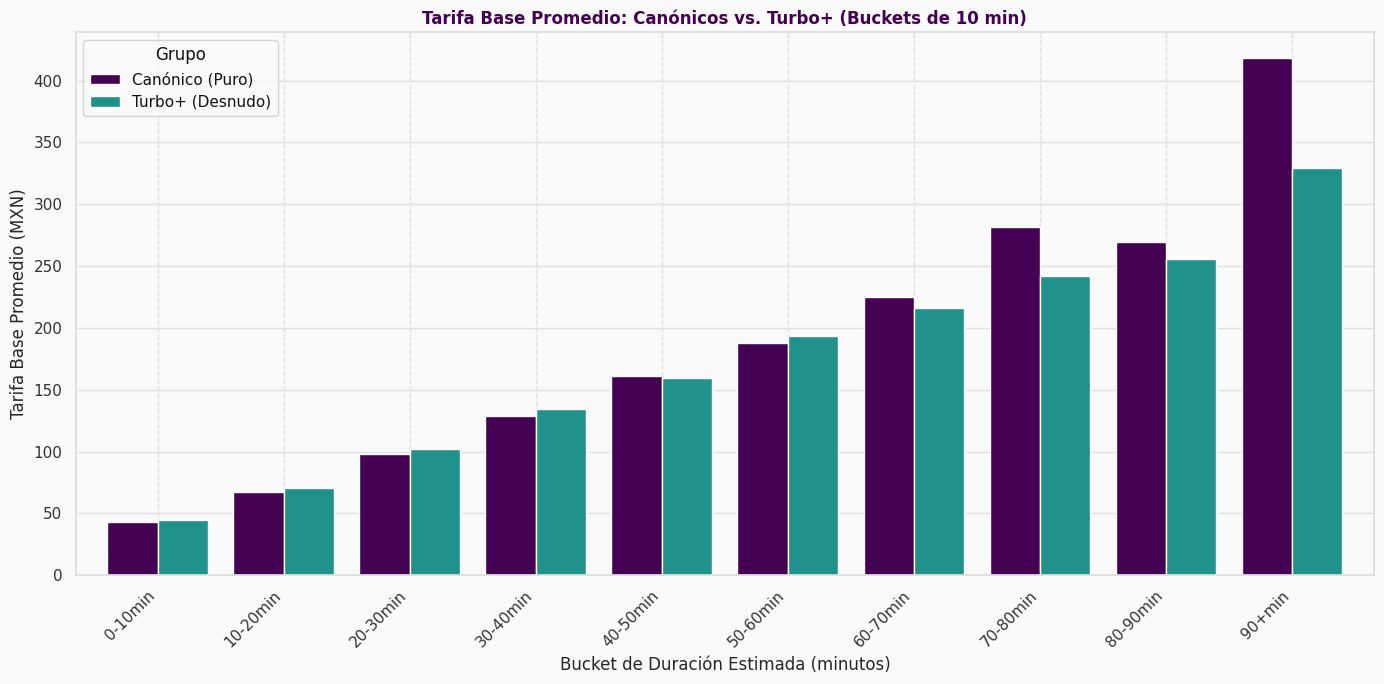

In [5]:
# ==============================================================================
# CELL 1.1: CAMPAÑA "SUBSIDIO OCULTO" (ANÁLISIS DE TURBO+ CON BUCKETS DE 10 MIN)
# ==============================================================================
# Purpose: Aislar y analizar el efecto del incentivo `Turbo+` en la tarifa base,
#          con una mayor resolución en los buckets de tiempo.
# ==============================================================================

from IPython.display import display, Markdown

if 'db_engine' in locals():

    # --- 1. INGESTA Y SEGMENTACIÓN ---
    # (Se asume que la ingesta y segmentación inicial ya se corrió en la celda anterior
    # y que los DataFrames 'df_control' y 'df_treatment_turbo' existen en memoria.
    # Si no, se debería re-ejecutar esa parte del código primero.)

    if 'df_control' in locals() and 'df_treatment_turbo' in locals():

        df_comparison_turbo = pd.concat([df_control, df_treatment_turbo])

        # --- 2. ANÁLISIS COMPARATIVO CON BUCKETS DE 10 MINUTOS ---

        display(Markdown("\n### 2.1. Comparación por Bucket de Tiempo (Resolución de 10 minutos)"))

        # Nuevos buckets de tiempo (de 0 a 90+ minutos en pasos de 10)
        # 600s = 10 min, 5400s = 90 min
        time_bins_10min = [0, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, float('inf')]
        time_labels_10min = [
            '0-10min', '10-20min', '20-30min', '30-40min', '40-50min',
            '50-60min', '60-70min', '70-80min', '80-90min', '90+min'
        ]

        df_comparison_turbo['time_bucket_10min'] = pd.cut(
            df_comparison_turbo['est_trip_time_sec'],
            bins=time_bins_10min,
            labels=time_labels_10min,
            right=False
        )

        time_comparison_10min = df_comparison_turbo.groupby(['time_bucket_10min', 'group'], observed=True)['base_fare'].mean().unstack()

        # Rellenar NaNs con 0 para que la gráfica no se rompa si un bucket no tiene datos
        time_comparison_10min = time_comparison_10min.fillna(0)

        time_comparison_10min.plot(kind='bar', figsize=(14, 7), width=0.8, color=[OPUS_PURPLE, OPUS_TEAL])

        plt.title('Tarifa Base Promedio: Canónicos vs. Turbo+ (Buckets de 10 min)', color=OPUS_PURPLE)
        plt.ylabel('Tarifa Base Promedio (MXN)')
        plt.xlabel('Bucket de Duración Estimada (minutos)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='x', linestyle='--')
        plt.legend(title='Grupo')
        plt.tight_layout()
        plt.show()


--- APLICANDO FILTRO DE UBERX ---
Grupo Canónico (UberX): 1523 ofertas
Grupo Turbo+ (UberX): 660 ofertas



### 2.1. Comparación por Bucket de Tiempo (UberX, Resolución de 10 minutos)

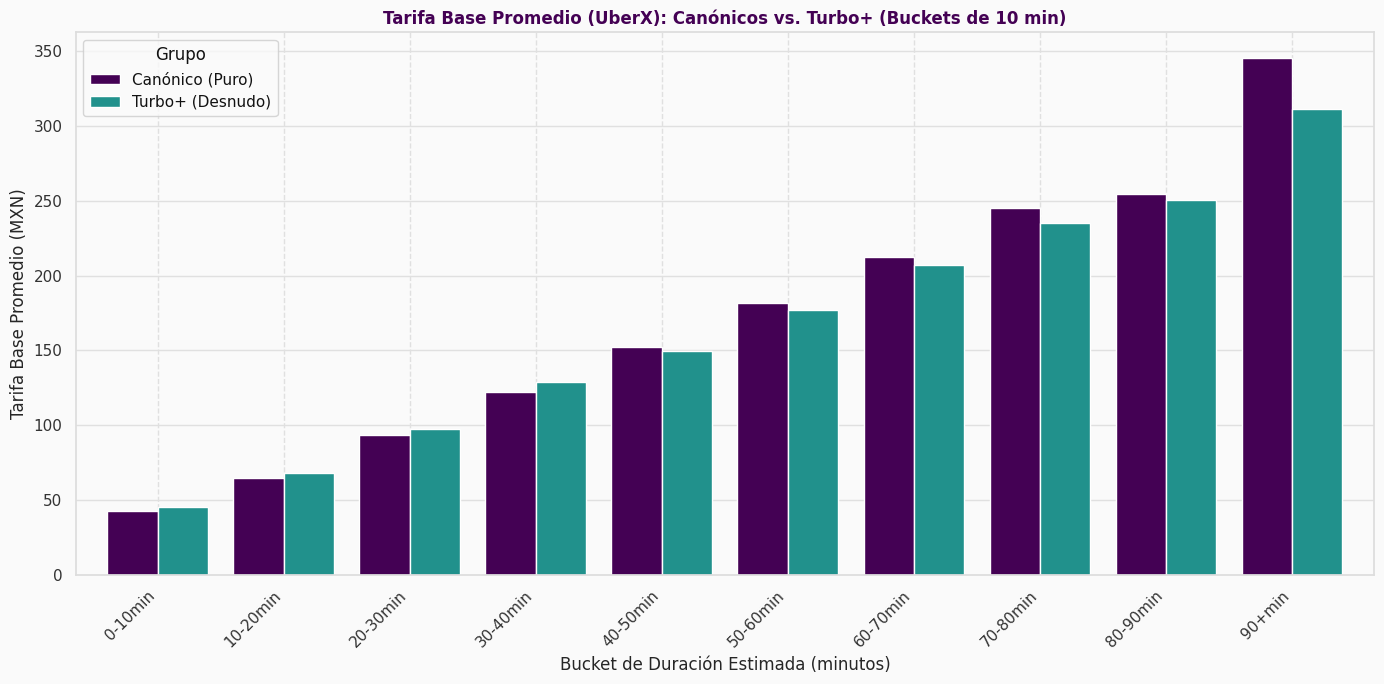

In [6]:
# ==============================================================================
# CELL 1.2: CAMPAÑA "SUBSIDIO OCULTO" (ANÁLISIS DE TURBO+ SOLO EN UBERX)
# ==============================================================================
# Purpose: Aislar y analizar el efecto del incentivo `Turbo+` en la tarifa base,
#          enfocándose exclusivamente en la categoría UberX.
# ==============================================================================

from IPython.display import display, Markdown

if 'db_engine' in locals():

    # --- 1. INGESTA Y SEGMENTACIÓN ---
    # (Se asume que los DataFrames 'df_control' y 'df_treatment_turbo' de la celda
    #  anterior existen en memoria.)

    if 'df_control' in locals() and 'df_treatment_turbo' in locals():

        # 1.1. FILTRO DE UBERX
        print("--- APLICANDO FILTRO DE UBERX ---")

        df_control_uberx = df_control[df_control['simplified_category'] == 'UberX'].copy()
        df_treatment_turbo_uberx = df_treatment_turbo[df_treatment_turbo['simplified_category'] == 'UberX'].copy()

        df_comparison_uberx = pd.concat([df_control_uberx, df_treatment_turbo_uberx])

        print(f"Grupo Canónico (UberX): {len(df_control_uberx)} ofertas")
        print(f"Grupo Turbo+ (UberX): {len(df_treatment_turbo_uberx)} ofertas")

        # --- 2. ANÁLISIS COMPARATIVO CON BUCKETS DE 10 MINUTOS ---

        display(Markdown("\n### 2.1. Comparación por Bucket de Tiempo (UberX, Resolución de 10 minutos)"))

        # Mismos buckets de tiempo
        time_bins_10min = [0, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, float('inf')]
        time_labels_10min = [
            '0-10min', '10-20min', '20-30min', '30-40min', '40-50min',
            '50-60min', '60-70min', '70-80min', '80-90min', '90+min'
        ]

        df_comparison_uberx['time_bucket_10min'] = pd.cut(
            df_comparison_uberx['est_trip_time_sec'],
            bins=time_bins_10min,
            labels=time_labels_10min,
            right=False
        )

        time_comparison_uberx = df_comparison_uberx.groupby(['time_bucket_10min', 'group'], observed=True)['base_fare'].mean().unstack()

        # Rellenar NaNs con 0 para que la gráfica no se rompa
        time_comparison_uberx = time_comparison_uberx.fillna(0)

        time_comparison_uberx.plot(kind='bar', figsize=(14, 7), width=0.8, color=[OPUS_PURPLE, OPUS_TEAL])

        plt.title('Tarifa Base Promedio (UberX): Canónicos vs. Turbo+ (Buckets de 10 min)', color=OPUS_PURPLE)
        plt.ylabel('Tarifa Base Promedio (MXN)')
        plt.xlabel('Bucket de Duración Estimada (minutos)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='x', linestyle='--')
        plt.legend(title='Grupo')
        plt.tight_layout()
        plt.show()


--- APLICANDO FILTRO DE MID-TIER ---
Grupo Canónico (Mid-Tier): 456 ofertas
Grupo Turbo+ (Mid-Tier): 183 ofertas



### 2.1. Comparación por Bucket de Tiempo (Mid-Tier, Resolución de 10 minutos)

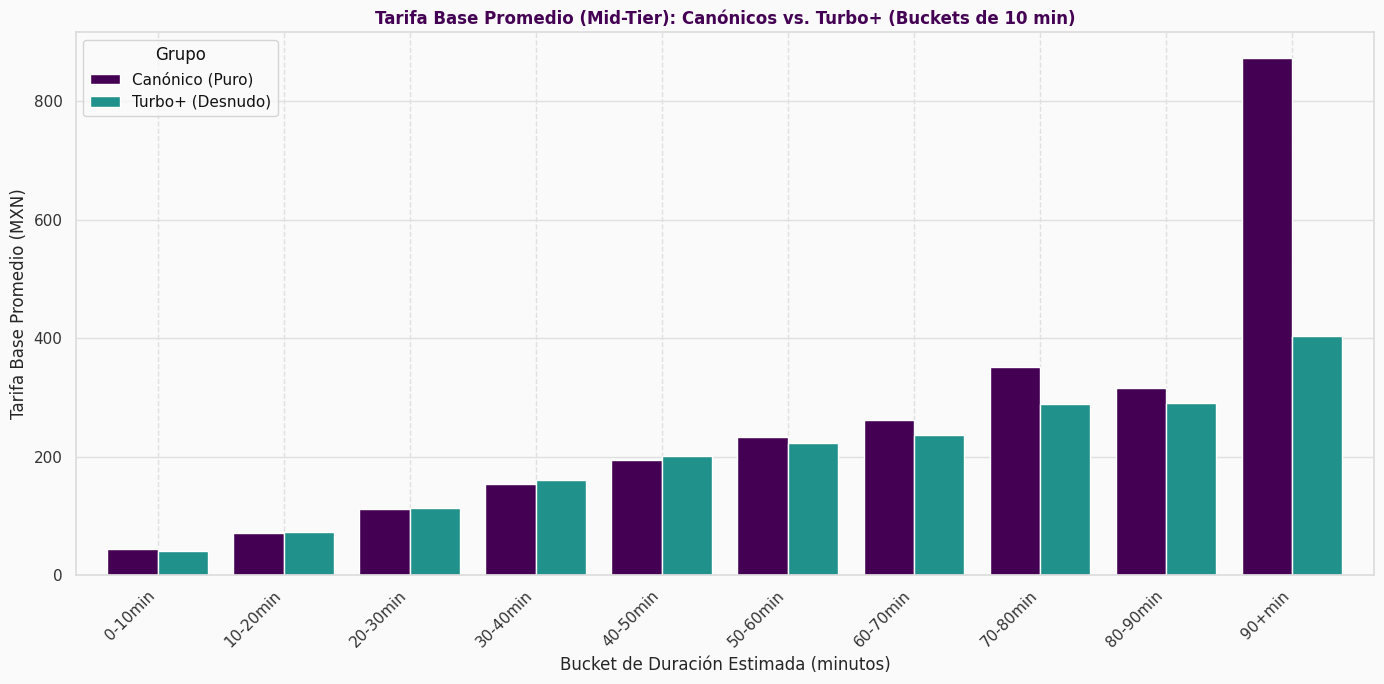

In [7]:
# ==============================================================================
# CELL 1.3: CAMPAÑA "SUBSIDIO OCULTO" (ANÁLISIS DE TURBO+ SOLO EN MID-TIER)
# ==============================================================================
# Purpose: Aislar y analizar el efecto del incentivo `Turbo+` en la tarifa base,
#          enfocándose exclusivamente en la categoría Mid-Tier.
# ==============================================================================

from IPython.display import display, Markdown

if 'db_engine' in locals():

    # --- 1. INGESTA Y SEGMENTACIÓN ---
    # (Se asume que los DataFrames 'df_control' y 'df_treatment_turbo' de la celda
    #  inicial existen en memoria.)

    if 'df_control' in locals() and 'df_treatment_turbo' in locals():

        # 1.1. FILTRO DE MID-TIER
        print("--- APLICANDO FILTRO DE MID-TIER ---")

        df_control_midtier = df_control[df_control['simplified_category'] == 'Mid-Tier'].copy()
        df_treatment_turbo_midtier = df_treatment_turbo[df_treatment_turbo['simplified_category'] == 'Mid-Tier'].copy()

        df_comparison_midtier = pd.concat([df_control_midtier, df_treatment_turbo_midtier])

        print(f"Grupo Canónico (Mid-Tier): {len(df_control_midtier)} ofertas")
        print(f"Grupo Turbo+ (Mid-Tier): {len(df_treatment_turbo_midtier)} ofertas")

        # --- 2. ANÁLISIS COMPARATIVO CON BUCKETS DE 10 MINUTOS ---

        display(Markdown("\n### 2.1. Comparación por Bucket de Tiempo (Mid-Tier, Resolución de 10 minutos)"))

        # Mismos buckets de tiempo
        time_bins_10min = [0, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, float('inf')]
        time_labels_10min = [
            '0-10min', '10-20min', '20-30min', '30-40min', '40-50min',
            '50-60min', '60-70min', '70-80min', '80-90min', '90+min'
        ]

        df_comparison_midtier['time_bucket_10min'] = pd.cut(
            df_comparison_midtier['est_trip_time_sec'],
            bins=time_bins_10min,
            labels=time_labels_10min,
            right=False
        )

        time_comparison_midtier = df_comparison_midtier.groupby(['time_bucket_10min', 'group'], observed=True)['base_fare'].mean().unstack()

        # Rellenar NaNs con 0 para que la gráfica no se rompa
        time_comparison_midtier = time_comparison_midtier.fillna(0)

        time_comparison_midtier.plot(kind='bar', figsize=(14, 7), width=0.8, color=[OPUS_PURPLE, OPUS_TEAL])

        plt.title('Tarifa Base Promedio (Mid-Tier): Canónicos vs. Turbo+ (Buckets de 10 min)', color=OPUS_PURPLE)
        plt.ylabel('Tarifa Base Promedio (MXN)')
        plt.xlabel('Bucket de Duración Estimada (minutos)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='x', linestyle='--')
        plt.legend(title='Grupo')
        plt.tight_layout()
        plt.show()



# **INVESTIGACIÓN: LA ESTRUCTURA DE PRECIOS POR TIER**

Este análisis pivota desde la comparación de incentivos hacia la deconstrucción de la estructura de precios fundamental de la plataforma. El objetivo es visualizar y cuantificar la **"Prima de Categoría"**: la diferencia en la tarifa base pagada entre `UberX`, `Mid-Tier` y `Black`.

### **Metodología: Segmentación por Duración y Categoría**

Utilizamos el `dataset` completo, con las tarifas base ya calculadas (desnudas de incentivos), y lo segmentamos a lo largo de dos ejes:
- **Eje de Duración:** Se utilizan "buckets" de 10 minutos para agrupar viajes de longitud similar.
- **Eje de Categoría:** Se utilizan las categorías simplificadas `UberX`, `Mid-Tier` y `Black`.

Al calcular la tarifa base promedio para cada una de estas celdas (`Duración x Categoría`), podemos observar cómo la prima de una categoría sobre otra evoluciona a medida que los viajes se hacen más largos.



--- 1. ANÁLISIS COMPARATIVO POR TIER Y BUCKET DE TIEMPO ---


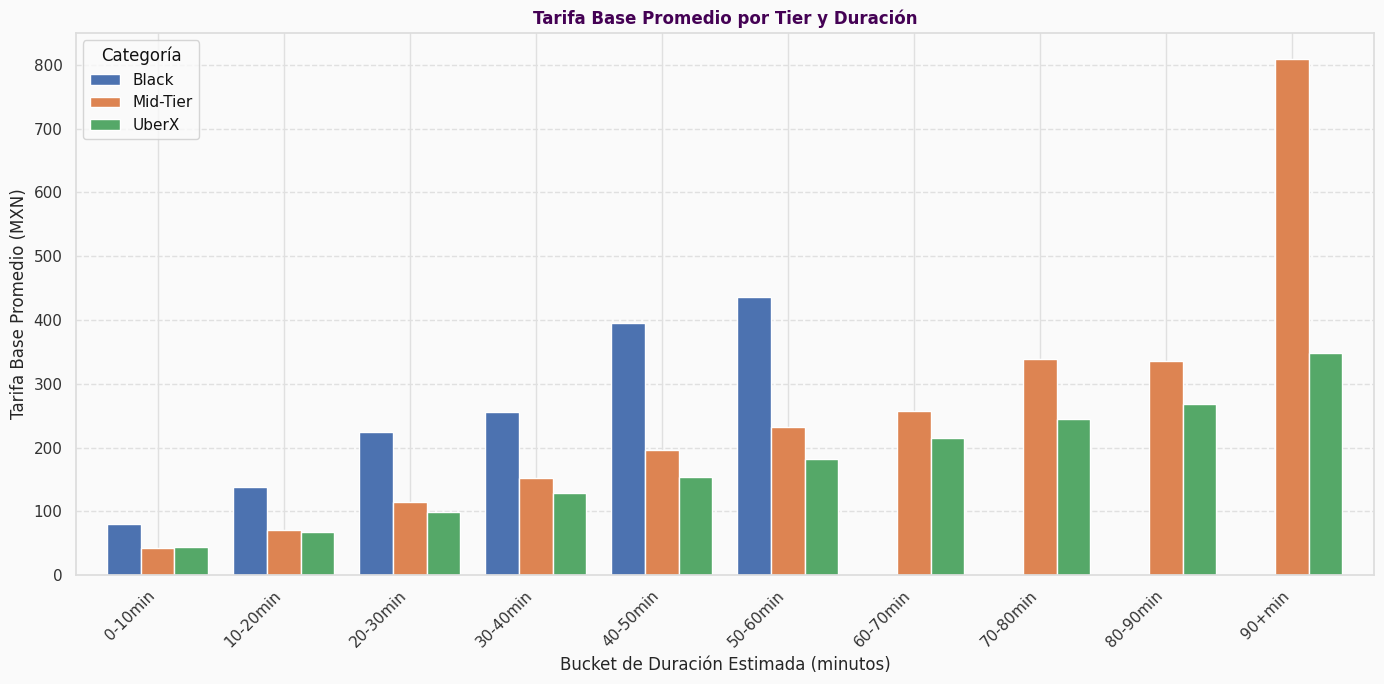

In [8]:
# ==============================================================================
# CELL 1.4: CAMPAÑA "SUBSIDIO OCULTO" (ANÁLISIS POR TIER Y DURACIÓN)
# ==============================================================================
# Purpose: Comparar la tarifa base promedio entre las categorías estratégicas
#          (UberX, Mid-Tier, Black) a través de buckets de tiempo de 10 minutos.
# ==============================================================================

from IPython.display import display, Markdown

# --- MANIFIESTO METODOLÓGICO ---

markdown_explanation = """
# **INVESTIGACIÓN: LA ESTRUCTURA DE PRECIOS POR TIER**

Este análisis pivota desde la comparación de incentivos hacia la deconstrucción de la estructura de precios fundamental de la plataforma. El objetivo es visualizar y cuantificar la **"Prima de Categoría"**: la diferencia en la tarifa base pagada entre `UberX`, `Mid-Tier` y `Black`.

### **Metodología: Segmentación por Duración y Categoría**

Utilizamos el `dataset` completo, con las tarifas base ya calculadas (desnudas de incentivos), y lo segmentamos a lo largo de dos ejes:
- **Eje de Duración:** Se utilizan "buckets" de 10 minutos para agrupar viajes de longitud similar.
- **Eje de Categoría:** Se utilizan las categorías simplificadas `UberX`, `Mid-Tier` y `Black`.

Al calcular la tarifa base promedio para cada una de estas celdas (`Duración x Categoría`), podemos observar cómo la prima de una categoría sobre otra evoluciona a medida que los viajes se hacen más largos.
"""
display(Markdown(markdown_explanation))


# --- EJECUCIÓN DEL CÓDIGO ---

if 'df_comp_global' in locals() and not df_comp_global.empty:

    print("\n--- 1. ANÁLISIS COMPARATIVO POR TIER Y BUCKET DE TIEMPO ---")

    try:
        df_analysis = df_comp_global.copy()

        # 1.1. CREAR BUCKETS DE 10 MINUTOS
        time_bins_10min = [0, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, float('inf')]
        time_labels_10min = [
            '0-10min', '10-20min', '20-30min', '30-40min', '40-50min',
            '50-60min', '60-70min', '70-80min', '80-90min', '90+min'
        ]

        df_analysis['time_bucket_10min'] = pd.cut(
            df_analysis['est_trip_time_sec'],
            bins=time_bins_10min,
            labels=time_labels_10min,
            right=False
        )

        # 1.2. FILTRAR SOLO CATEGORÍAS ESTRATÉGICAS
        df_analysis = df_analysis[df_analysis['simplified_category'].isin(['UberX', 'Mid-Tier', 'Black'])]

        # 1.3. AGRUPAR Y PIVOTAR
        tier_time_comparison = df_analysis.groupby(['time_bucket_10min', 'simplified_category'], observed=True)['base_fare'].mean().unstack()

        # Rellenar NaNs con 0 para que la gráfica no se rompa
        tier_time_comparison = tier_time_comparison.fillna(0)

        # 1.4. VISUALIZACIÓN
        tier_time_comparison.plot(kind='bar', figsize=(14, 7), width=0.8)

        plt.title('Tarifa Base Promedio por Tier y Duración', color=OPUS_PURPLE)
        plt.ylabel('Tarifa Base Promedio (MXN)')
        plt.xlabel('Bucket de Duración Estimada (minutos)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--')
        plt.legend(title='Categoría')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"🔴 ERROR CRÍTICO durante el análisis por Tier: {e}")

else:
    print("🔴 No se puede ejecutar la campaña. El DataFrame `df_comp_global` no está definido.")

In [9]:
# ==============================================================================
# CELL 1.5: CUANTIFICACIÓN DE LA "PRIMA DE CATEGORÍA"
# ==============================================================================
# Purpose: Calcular y visualizar el aumento porcentual en la tarifa base de
#          Mid-Tier y Black en comparación con UberX, por bucket de tiempo.
# ==============================================================================

from IPython.display import display, Markdown

# Asumimos que la celda anterior se ejecutó y 'tier_time_comparison' existe en memoria.

if 'tier_time_comparison' in locals() and not tier_time_comparison.empty:

    # 1. CÁLCULO DE LA PRIMA DE CATEGORÍA
    print("--- 1. CALCULANDO LA PRIMA DE CATEGORÍA ---")

    df_prima = tier_time_comparison.copy()

    # La prima es el % de aumento sobre la base (UberX)
    df_prima['Prima_MidTier_vs_UberX'] = (df_prima['Mid-Tier'] / df_prima['UberX'].replace(0, np.nan)) - 1
    df_prima['Prima_Black_vs_UberX'] = (df_prima['Black'] / df_prima['UberX'].replace(0, np.nan)) - 1

    # Seleccionamos y renombramos las columnas para el reporte
    df_prima_report = df_prima[['Prima_MidTier_vs_UberX', 'Prima_Black_vs_UberX']].fillna(0)

    # 2. PRESENTACIÓN DE LA TABLA
    display(Markdown("\n### 2.1. Tabla de Prima de Categoría (Aumento % vs. UberX)"))
    display(df_prima_report.style.format('{:+.1%}')
                             .background_gradient(cmap='viridis')
                             .set_caption("Evolución de la prima de categoría por duración del viaje."))

    # 3. VISUALIZACIÓN DE LA DIVERGENCIA

    # Graficamos solo las primas para ver la tendencia
    df_prima_plot = df_prima_report.reset_index()
    # Convertimos los porcentajes a puntos para la gráfica
    df_prima_plot['Prima_MidTier_vs_UberX'] *= 100
    df_prima_plot['Prima_Black_vs_UberX'] *= 100

    plt.figure(figsize=(12, 7))

    plt.plot(df_prima_plot['time_bucket'], df_prima_plot['Prima_Black_vs_UberX'],
             label='Prima de Black (vs. UberX)', marker='o', color=OPUS_PURPLE, linewidth=2.5)

    plt.plot(df_prima_plot['time_bucket'], df_prima_plot['Prima_MidTier_vs_UberX'],
             label='Prima de Mid-Tier (vs. UberX)', marker='s', color=OPUS_TEAL, linewidth=2.5)

    plt.title('Divergencia de Valor: Evolución de la Prima de Categoría por Duración', color=OPUS_PURPLE)
    plt.xlabel('Bucket de Duración Estimada (minutos)')
    plt.ylabel('Aumento Porcentual en Tarifa Base (vs. UberX)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--')
    plt.legend()
    plt.axhline(0, color='grey', linestyle='-')

    # Añadir formato de porcentaje al eje Y
    from matplotlib.ticker import PercentFormatter
    plt.gca().yaxis.set_major_formatter(PercentFormatter())

    plt.tight_layout()
    plt.show()

else:
    print("🔴 No se puede ejecutar el análisis. El DataFrame 'tier_time_comparison' no está definido.")

--- 1. CALCULANDO LA PRIMA DE CATEGORÍA ---



### 2.1. Tabla de Prima de Categoría (Aumento % vs. UberX)

simplified_category,Prima_MidTier_vs_UberX,Prima_Black_vs_UberX
time_bucket_10min,,
0-10min,-4.2%,+82.0%
10-20min,+4.2%,+105.3%
20-30min,+16.7%,+128.1%
30-40min,+18.9%,+98.7%
40-50min,+26.9%,+156.0%
50-60min,+27.0%,+138.7%
60-70min,+19.9%,-100.0%
70-80min,+38.2%,-100.0%
80-90min,+24.7%,-100.0%


KeyError: 'time_bucket'

<Figure size 1200x700 with 0 Axes>